# Conociendo datasets con datos faltantes

Descarga, exploración y visualización inicial de los datasets del proyecto.

In [1]:
import matplotlib.pyplot as plt
import missingno as msno
import pandas as pd
import seaborn as sns

from src.data_loader import load_all_datasets

In [2]:
datasets = load_all_datasets()
print(f"Datasets cargados: {', '.join(datasets)}")

Datasets cargados: oceanbuoys, pedestrian, riskfactors, pima


## Exploración inicial

In [3]:
summary = pd.DataFrame({
    name: {
        'filas': dataset.shape[0],
        'columnas': dataset.shape[1],
        'valores_faltantes': int(dataset.isna().sum().sum()),
    }
    for name, dataset in datasets.items()
}).T
summary

,filas,columnas,valores_faltantes
oceanbuoys,736,8,177
pedestrian,37700,9,2548
riskfactors,245,34,1186
pima,768,9,0


In [4]:
datasets['pima'].head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


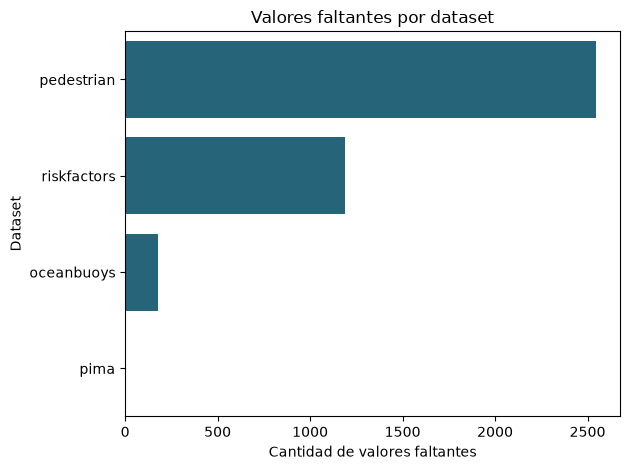

In [5]:
missing_by_dataset = summary['valores_faltantes'].sort_values(ascending=False)
sns.barplot(x=missing_by_dataset.values, y=missing_by_dataset.index, color='#176b87')
plt.title('Valores faltantes por dataset')
plt.xlabel('Cantidad de valores faltantes')
plt.ylabel('Dataset')
plt.tight_layout()
plt.show()

oceanbuoys


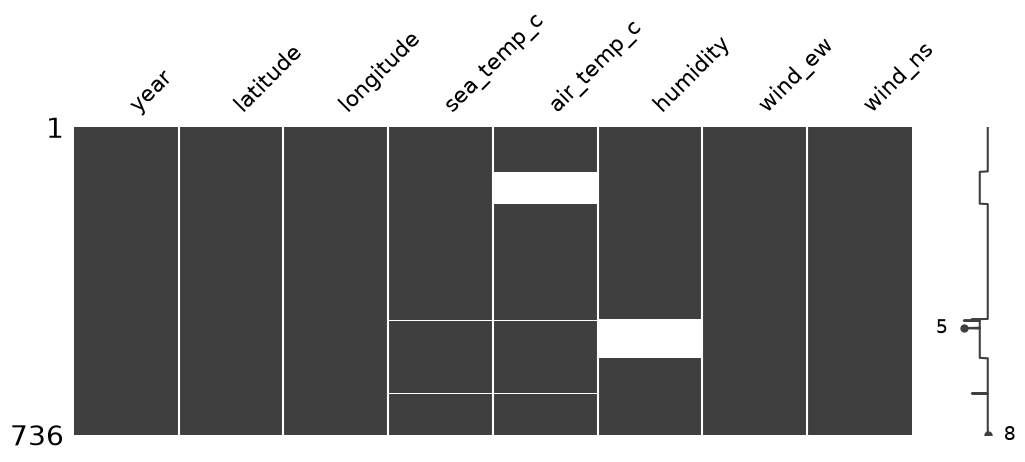

pedestrian


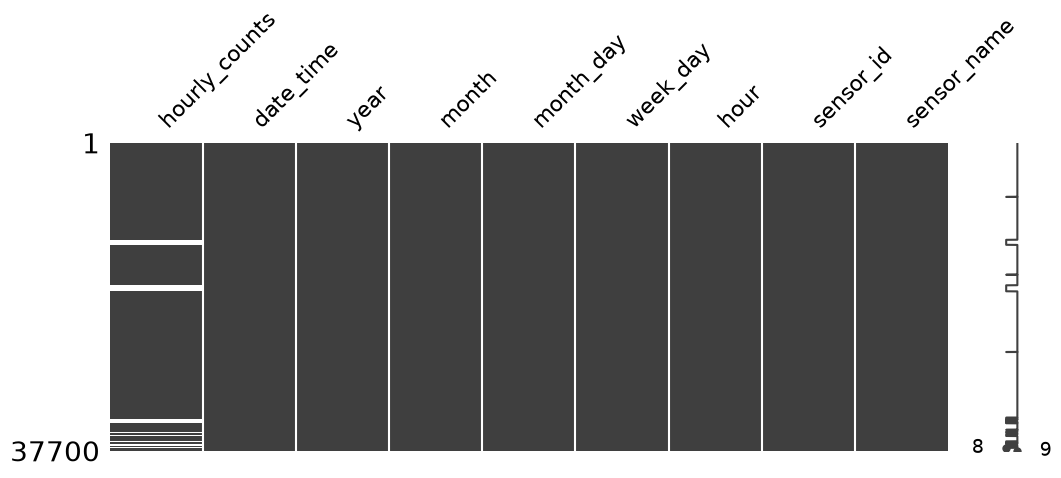

riskfactors


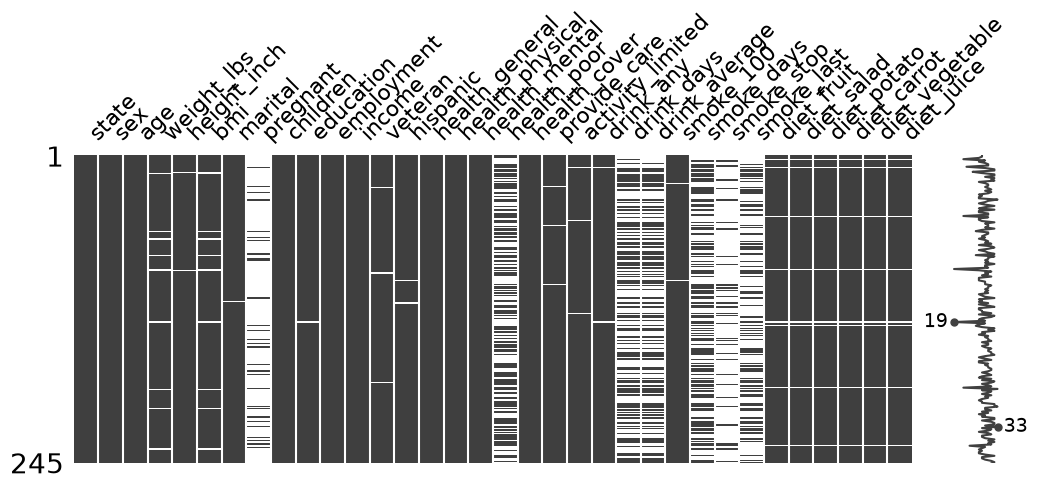

In [6]:
for name, dataset in datasets.items():
    if dataset.isna().any().any():
        print(name)
        msno.matrix(dataset, figsize=(12, 4))
        plt.show()